# How warm was Oklahoma City on 6 May 2024 compared with its hourly normals?

Compare routine observations at Will Rogers World Airport with its 1991–2020 hourly temperature normals. The [manifest](dataset.yaml) names both sources; the calculation keeps the original files and checksums intact.

This example requires usdata v0.23.0 or later for hourly normals support. See the [run instructions](https://usdata.dev/studies/#run) and [NOAA normals guide](https://docs.usdata.dev/providers/noaa-normals/).


In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from usdata import pull, verify

manifest = Path("dataset.yaml")
result = pull(manifest)
observations = result.one("observations").open(dtype={"DATE": "string"})
normals = result.one("normals").open(dtype={"DATE": "string"})
print(f"Fetched {len(observations)} LCD reports and {len(normals)} hourly normals.")
print(f"Lockfile pins {len(result.lockfile.assets)} assets.")

Fetched 60 LCD reports and 48 hourly normals.
Lockfile pins 2 assets.


## Align the station and the clock

LCD uses `72353013967`; normals use `USW00013967` for this airport. Both date columns label **local standard time** (CST here, UTC−6 throughout the year). Do not localize them to a daylight-saving timezone: May civil time would shift the comparison by an hour.

Keep routine hourly METAR reports (`FM-15`), not specials or daily summaries. The reports occur at `:52`; match to the nearest normal within ten minutes. This is an explicit approximation, not an hourly observed mean. The last report matches May 7 at midnight, so the manifest requests May 6–7 normals. We retain actual report times and count invalid or unmatched rows.

The normals' yearless labels are mapped onto 2024 only for this comparison. [NOAA's hourly documentation](https://www.ncei.noaa.gov/pub/data/cdo/documentation/normals-hourly-1991-2020_documentation.pdf) describes local standard time, missing values, and the 15-day windows pooled over 30 years. There are no February 29 normals.


In [2]:
assert set(observations["STATION"]) == {"72353013967"}
assert set(normals["STATION"]) == {"USW00013967"}
reports = observations.loc[observations["REPORT_TYPE"].str.strip().eq("FM-15")].copy()
reports["observed_at"] = pd.to_datetime(reports["DATE"], format="%Y-%m-%dT%H:%M:%S")
# Flagged strings stay invalid; do not silently strip quality suffixes.
reports["observed_c"] = pd.to_numeric(reports["HourlyDryBulbTemperature"], errors="coerce")
reports["observed_c"] = reports["observed_c"].mask(reports["observed_c"].eq(-9999))
normals["normal_at"] = pd.to_datetime("2024-" + normals["DATE"], format="%Y-%m-%dT%H:%M:%S")
normals["normal_c"] = pd.to_numeric(normals["HLY-TEMP-NORMAL"], errors="coerce")
normals["normal_c"] = normals["normal_c"].mask(normals["normal_c"].eq(-9999))
assert not normals["normal_at"].duplicated().any()
comparison = pd.merge_asof(
    reports[["observed_at", "observed_c"]].sort_values("observed_at"),
    normals[["normal_at", "normal_c"]].sort_values("normal_at"),
    left_on="observed_at",
    right_on="normal_at",
    direction="nearest",
    tolerance=pd.Timedelta(minutes=10),
)
comparison["departure_c"] = comparison["observed_c"] - comparison["normal_c"]
comparison["offset_minutes"] = (
    comparison["normal_at"] - comparison["observed_at"]
).dt.total_seconds() / 60
usable = comparison.dropna(subset=["departure_c"])
assert len(usable) > 0, "No usable matched temperatures; inspect the source tables."
print(f"Routine reports: {len(reports)}; other report types: {len(observations) - len(reports)}")
print(f"Invalid observations: {comparison.observed_c.isna().sum()}")
print(f"Invalid normals: {normals.normal_c.isna().sum()}")
print(f"Unmatched reports: {comparison.normal_at.isna().sum()}; usable pairs: {len(usable)}")
comparison

Routine reports: 24; other report types: 36
Invalid observations: 0
Invalid normals: 0
Unmatched reports: 0; usable pairs: 24


,observed_at,observed_c,normal_at,normal_c,departure_c,offset_minutes
0,2024-05-06 00:52:00,16.1,2024-05-06 01:00:00,15.6,0.5,8.0
1,2024-05-06 01:52:00,15.6,2024-05-06 02:00:00,15.1,0.5,8.0
2,2024-05-06 02:52:00,16.1,2024-05-06 03:00:00,14.8,1.3,8.0
3,2024-05-06 03:52:00,16.1,2024-05-06 04:00:00,14.5,1.6,8.0
4,2024-05-06 04:52:00,16.7,2024-05-06 05:00:00,14.3,2.4,8.0
5,2024-05-06 05:52:00,17.2,2024-05-06 06:00:00,14.2,3.0,8.0
6,2024-05-06 06:52:00,17.8,2024-05-06 07:00:00,15.2,2.6,8.0
7,2024-05-06 07:52:00,19.4,2024-05-06 08:00:00,16.8,2.6,8.0
8,2024-05-06 08:52:00,20.0,2024-05-06 09:00:00,18.4,1.6,8.0
9,2024-05-06 09:52:00,21.7,2024-05-06 10:00:00,19.7,2.0,8.0


## Temperature departures

`HLY-TEMP-NORMAL` and `HourlyDryBulbTemperature` are requested in metric units. The hourly normal's conversion was checked against standard-unit responses for this station before the example was written; that check does not establish the units of every other normals variable.

A positive departure means warmer than the matched hourly mean. It does not establish a percentile, a trend, or statistical rarity. These are individual reports compared with calendar normals, not daily means.


24 of 24 usable reports were warmer than the matched normal.
Mean departure across matched reports: 2.88 C
Largest warm departure: 7.5 C at 2024-05-06 21:52 CST
Matched normal: 2024-05-06 22:00 CST (8 minutes later)


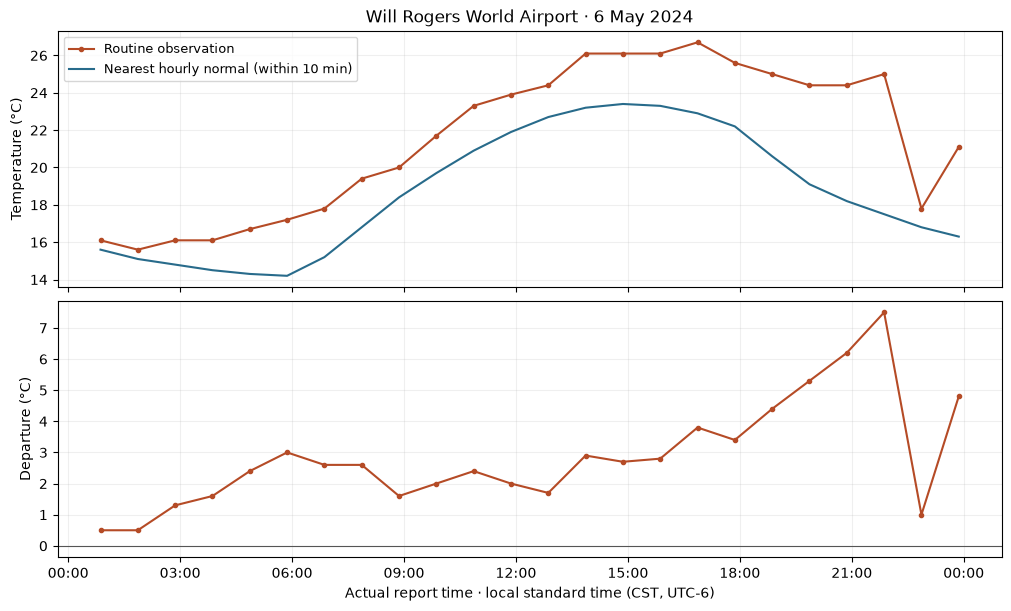

In [3]:
warm = usable["departure_c"].gt(0).sum()
peak = usable.loc[usable["departure_c"].idxmax()]
print(f"{warm} of {len(usable)} usable reports were warmer than the matched normal.")
print(f"Mean departure across matched reports: {usable.departure_c.mean():.2f} C")
print(f"Largest warm departure: {peak.departure_c:.1f} C at {peak.observed_at:%Y-%m-%d %H:%M} CST")
print(
    f"Matched normal: {peak.normal_at:%Y-%m-%d %H:%M} CST ({peak.offset_minutes:.0f} minutes later)"
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, constrained_layout=True)
axes[0].plot(
    usable["observed_at"],
    usable["observed_c"],
    marker=".",
    color="#b54b26",
    label="Routine observation",
)
axes[0].plot(
    usable["observed_at"],
    usable["normal_c"],
    color="#286b8b",
    label="Nearest hourly normal (within 10 min)",
)
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("Will Rogers World Airport · 6 May 2024")
axes[0].legend(loc="upper left", fontsize=9)
axes[1].plot(usable["observed_at"], usable["departure_c"], marker=".", color="#b54b26")
axes[1].axhline(0, color="#555555", linewidth=0.8)
axes[1].set_ylabel("Departure (°C)")
axes[1].set_xlabel("Actual report time · local standard time (CST, UTC-6)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
for axis in axes:
    axis.grid(alpha=0.2)
plt.show()

## Verify and restore the pinned inputs

Restore the same lockfile into an empty temporary cache and compare every checksum. This proves exact restoration at the time of execution. NCEI can revise these query responses; keep the manifest, lockfile, and cached bytes together. A later mismatch should be reviewed before accepting an update.


In [4]:
assert verify(manifest) == []
with TemporaryDirectory(prefix="usdata-hourly-restore-") as fresh:
    restored = pull(manifest, root=fresh)
    assert restored.from_lockfile
    assert all(not item.from_cache for item in restored.fetched)
    assert restored.lockfile == result.lockfile
    assert verify(manifest, root=fresh) == []
    for name in ("observations", "normals"):
        original = result.one(name)
        copy = restored.one(name)
        assert copy.path.read_bytes() == original.path.read_bytes()
        print(name, copy.provenance.checksum)
print("Both inputs restored byte-for-byte into an empty cache and passed verification.")

observations sha256:8de03b216a814c25277f172c935082818893393e9731951007d5ea15613b972f
normals sha256:8a57959c59bf2a9df81fec170f9d4678d666c9d909826bbbba5d67f6e618bad6
Both inputs restored byte-for-byte into an empty cache and passed verification.


## What was awkward

- One airport has different identifiers in LCD and normals. The manifest spells out both; no automatic station crosswalk is assumed.
- Local standard time looks like an ordinary timestamp but must not follow daylight saving time. The normals also omit the year and February 29.
- Routine observations occur eight minutes before the nearest normal. The tolerance is an analysis choice, and the final report needs the next day's midnight normal.
- LCD mixes report types and can attach quality suffixes to numbers. The comparison reports excluded types and invalid values instead of treating every row as an hourly temperature.
